# Assignment 1 — Data Preparation

## 1. Identifying the Prediction Target

The target is y - whether the client subscribed to a term deposit. It's the right column to predict because it's the actual outcome of the campaign and isn't known until after the interaction is complete.

Two columns that look like valid targets but aren't:
- duration - call duration in seconds. Only known after the call ends, so it's unavailable at prediction time. Using it would be data leakage — the model would be cheating.
- campaign - number of contacts made during this campaign. This is an input to the process controlled by the bank, not the client's response. It describes what was done, not what happened as a result.

## 2. Data Loading and Exploration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE

In [ ]:
df = pd.read_csv('bank-additional-full.csv', sep=';')
print(f"Shape: {df.shape}  ({df.shape[0]} rows, {df.shape[1]} columns)")
print(f"\nColumn names:\n{list(df.columns)}")

In [ ]:
df.info()

In [20]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [21]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [ ]:
numerical_cols = df.select_dtypes(include='number').columns.tolist()
categorical_cols = df.select_dtypes(include='str').columns.tolist()
print(f"Numerical ({len(numerical_cols)}):   {numerical_cols}")
print(f"Categorical ({len(categorical_cols)}): {categorical_cols}")

In [ ]:
# explicit missing values (actual NaN)
print("=== Explicit NaN values ===")
print(df.isnull().sum())

# implicit missing values — 'unknown' is used as a placeholder
print("\n=== Implicit missing values ('unknown') ===")
print((df == 'unknown').sum())

No actual NaN values, but several columns use `"unknown"` as a placeholder — `default` is the worst (21% unknown). Also, `pdays = 999` means the client was never previously contacted, not an actual day count.

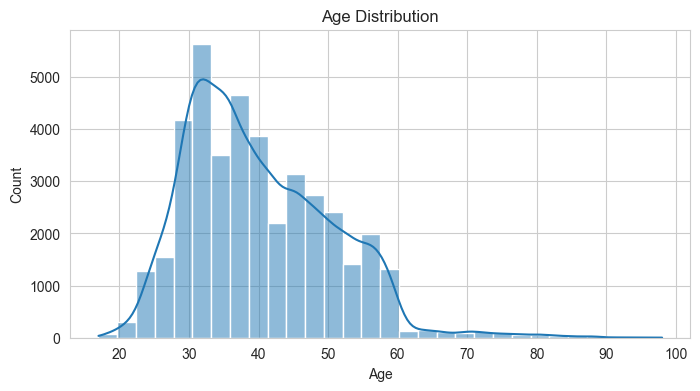

In [23]:
# age distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

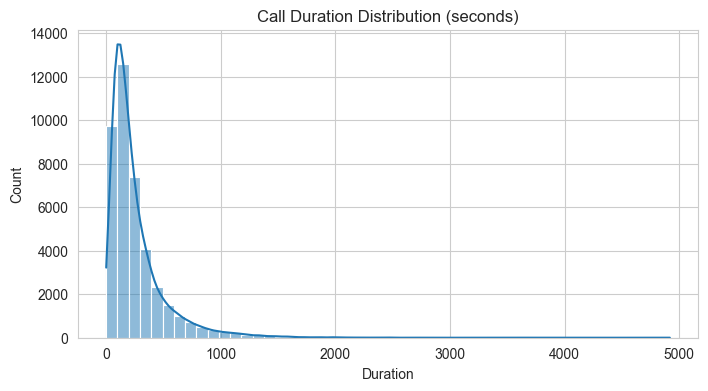

In [24]:
# call duration — this one is super skewed
plt.figure(figsize=(8, 4))
sns.histplot(df['duration'], bins=50, kde=True)
plt.title('Call Duration Distribution (seconds)')
plt.xlabel('Duration')
plt.ylabel('Count')
plt.show()

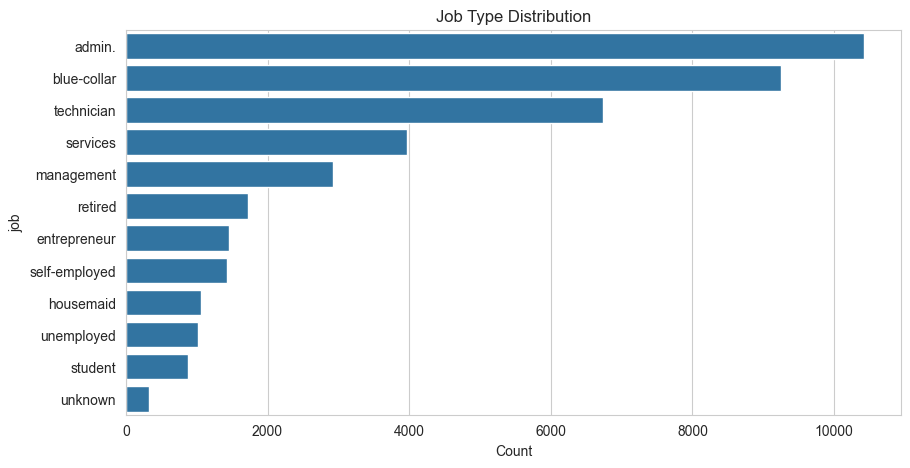

In [25]:
# job type distribution
plt.figure(figsize=(10, 5))
sns.countplot(y='job', data=df, order=df['job'].value_counts().index)
plt.title('Job Type Distribution')
plt.xlabel('Count')
plt.show()

In [ ]:
counts = df['y'].value_counts()
pcts = df['y'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.index, counts.values, color=['steelblue', 'salmon'])
for bar, pct in zip(bars, pcts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{pct:.1f}%', ha='center', fontsize=12)
ax.set_title('Target Variable Distribution')
ax.set_xlabel('Subscribed (y)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

- **Age** — roughly normal, most clients between 25–55.
- **Duration** — very skewed, and more importantly not available at prediction time (you only know the call length after it ends). Will drop this before modeling.
- **Job** — admin, blue-collar, and technician dominate. There's an "unknown" category too.
- **Target (y)** — 89% "no", 11% "yes". A model that always predicts "no" gets 89% accuracy, so accuracy alone is a bad metric here.

---
## 3. Task Ordering

The tasks are listed alphabetically in the assignment, but the order matters a lot. The rule is: **split before fitting any transformation**. Once you split, all learned parameters (encoder categories, scaler mean/std, imputation values, SMOTE) must come from training only.

| Step | Task | What's allowed | What must NOT be used | Leakage if wrong |
|------|------|---------------|----------------------|-----------------|
| 1 | Identify target | All columns, raw data | Nothing to fit yet | N/A |
| 2 | Explore data | Full dataset (just reading) | Can't fit transformations | N/A — we're only looking |
| 3 | Task ordering | Knowledge of the problem | — | N/A |
| 4 | **Split data** | Full dataset | — | **Boundary** — everything below is training-only |
| 5 | Missing values | Training set only for mode/imputation | Val/test statistics | Imputing with global mean leaks test distribution |
| 6 | Encode categoricals | Training categories only | Test set categories | Encoder that "knows" test categories inflates performance |
| 7 | Scale features | Training mean/std only | Val/test mean/std | Scaler fitted on all data leaks test stats into normalization |
| 8 | Feature selection | Training correlations/variance | Test set patterns | Removing features based on full-data correlation uses test info |
| 9 | SMOTE | Training set only | Val/test samples | Synthetic samples from test neighbors contaminate training |
| 10 | Train model | Resampled training set | Val/test labels | Evaluating on data seen during training isn't a real test |

**Example of bad ordering:** say you scale first, then split. The scaler computes mean and std from all 41k rows including the test set. When the model is evaluated on test, those samples already influenced the preprocessing — the test set isn't truly unseen. Performance looks better than it would be in production.

---
## 4. Data Splitting

Split before any learned transformations. Dropping `duration` first (data leakage), then a 60/20/20 stratified split. Stratification ensures the same 11% positive rate in all three sets — without it, you could end up with almost no "yes" samples in one split by chance.

In [27]:
# drop duration — not available at prediction time
df = df.drop(columns=['duration'])

# convert target to 0/1
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# separate features and target
X = df.drop(columns=['y'])
y = df['y']

# first split: 60% train, 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

# second split: split the 40% into 20% val and 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape[0]} samples ({y_train.mean():.3f} positive rate)")
print(f"Val:   {X_val.shape[0]} samples ({y_val.mean():.3f} positive rate)")
print(f"Test:  {X_test.shape[0]} samples ({y_test.mean():.3f} positive rate)")

Train: 24712 samples (0.113 positive rate)
Val:   8238 samples (0.113 positive rate)
Test:  8238 samples (0.113 positive rate)


Positive rate is ~11.3% across all three sets — stratification worked.

---
## 5. Managing Missing Values

No real NaNs, but two forms of hidden missingness:

**Data cleaning decisions** (fixing bad data entries):
- `"unknown"` strings in categorical columns — for columns with few unknowns (job 0.8%, marital 0.2%, education 4.3%, housing/loan 2.5%) I replace with the mode from the training set. These are likely just missing data, not meaningful.
- `pdays = 999` — this is a sentinel code meaning "never previously contacted", not an actual day count. I replace it with 0 and create a separate binary flag.

**Modeling decisions** (cases where missingness itself might carry information):
- `default = "unknown"` — 21% of training rows have this. That's too much to impute without introducing serious noise. More importantly, a client with unknown credit default status might behave differently from one with a known status — so keeping `"unknown"` as its own category lets the model learn from it.

Mode is computed from training only, then applied to val/test. Otherwise the imputation would use statistics from data the model shouldn't have seen.

In [ ]:
# let's see what we're dealing with in the training set
print("Unknown counts in training set:")
for col in X_train.select_dtypes(include='str').columns:
    n_unknown = (X_train[col] == 'unknown').sum()
    if n_unknown > 0:
        print(f"  {col}: {n_unknown} ({n_unknown/len(X_train)*100:.1f}%)")

print(f"\npdays == 999 in training set: {(X_train['pdays'] == 999).sum()} ({(X_train['pdays'] == 999).mean()*100:.1f}%)")

In [ ]:
# replace unknowns with mode from training set (except default)
cols_to_impute = ['job', 'marital', 'education', 'housing', 'loan']

for col in cols_to_impute:
    # get mode from training set only 
    mode_val = X_train[col][X_train[col] != 'unknown'].mode()[0]
    print(f"  {col}: replacing 'unknown' with '{mode_val}'")
    
    X_train[col] = X_train[col].replace('unknown', mode_val)
    X_val[col] = X_val[col].replace('unknown', mode_val)
    X_test[col] = X_test[col].replace('unknown', mode_val)

# handle pdays sentinel
# create binary flag first, then replace 999 with 0
for dataset in [X_train, X_val, X_test]:
    dataset['previously_contacted'] = (dataset['pdays'] != 999).astype(int)
    dataset['pdays'] = dataset['pdays'].replace(999, 0)

print(f"\nUnknowns left in training set: {(X_train == 'unknown').sum().sum()}")
print(f"(all in 'default' column — keeping those on purpose)")

  job: replacing 'unknown' with 'admin.'
  marital: replacing 'unknown' with 'married'
  education: replacing 'unknown' with 'university.degree'
  housing: replacing 'unknown' with 'yes'
  loan: replacing 'unknown' with 'no'

Unknowns left in training set: 5210
(all in 'default' column — keeping those on purpose)


---
## 6. Encoding Categorical Variables

Logistic regression needs numbers, so the categorical columns need encoding.

- **`education`** → ordinal encoding, since there's a clear order (illiterate < basic.4y < ... < university.degree). The model can learn one coefficient that captures the directional effect of education level.
- **Everything else** → one-hot encoding, since there's no meaningful order (e.g. job types, months). Using `drop='first'` avoids perfect multicollinearity — the dropped category becomes the reference point.

Both encoders are fit on training only. If we fitted on all data, the encoder would know about categories in the test set before seeing them.

**Effect on the dataset:**
- *Dimensionality*: went from 10 categorical columns to 33 encoded ones (32 OHE + 1 ordinal). Each category gets its own binary column, so the model can learn a separate coefficient for each job type, month, etc.
- *Interpretability*: each OHE coefficient now represents the effect of being in that specific category vs the reference category. This is more interpretable than, say, label encoding where the model would assume ordinal relationships that don't exist.
- *Decision boundaries*: logistic regression draws a linear boundary in feature space. OHE lets the model shift that boundary differently for each category value — something it couldn't do if we just assigned arbitrary integers to categories.

In [ ]:
# figure out which columns are still categorical
cat_cols = X_train.select_dtypes(include='str').columns.tolist()
print(f"Categorical columns: {cat_cols}")
print(f"Before encoding — shape: {X_train.shape}")

In [31]:
# ordinal encoding for education
edu_order = ['illiterate', 'basic.4y', 'basic.6y', 'basic.9y', 
             'high.school', 'university.degree', 'professional.course']

ord_enc = OrdinalEncoder(categories=[edu_order], handle_unknown='use_encoded_value', unknown_value=-1)

X_train['education'] = ord_enc.fit_transform(X_train[['education']])
X_val['education'] = ord_enc.transform(X_val[['education']])
X_test['education'] = ord_enc.transform(X_test[['education']])

print("Education encoding:")
for i, level in enumerate(edu_order):
    print(f"  {level} → {i}")

Education encoding:
  illiterate → 0
  basic.4y → 1
  basic.6y → 2
  basic.9y → 3
  high.school → 4
  university.degree → 5
  professional.course → 6


In [32]:
# one-hot encoding for the rest of the categorical columns
nominal_cols = [c for c in cat_cols if c != 'education']
print(f"One-hot encoding these: {nominal_cols}")

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
ohe.fit(X_train[nominal_cols])

# transform and create dataframes with proper column names
train_ohe = pd.DataFrame(
    ohe.transform(X_train[nominal_cols]),
    columns=ohe.get_feature_names_out(nominal_cols),
    index=X_train.index
)
val_ohe = pd.DataFrame(
    ohe.transform(X_val[nominal_cols]),
    columns=ohe.get_feature_names_out(nominal_cols),
    index=X_val.index
)
test_ohe = pd.DataFrame(
    ohe.transform(X_test[nominal_cols]),
    columns=ohe.get_feature_names_out(nominal_cols),
    index=X_test.index
)

# drop the original categorical columns and join the encoded ones
X_train = X_train.drop(columns=nominal_cols).join(train_ohe)
X_val = X_val.drop(columns=nominal_cols).join(val_ohe)
X_test = X_test.drop(columns=nominal_cols).join(test_ohe)

print(f"\nAfter encoding — shape: {X_train.shape}")
print(f"Went from {len(cat_cols)} categorical columns to {len(ohe.get_feature_names_out(nominal_cols))} one-hot + 1 ordinal")

One-hot encoding these: ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

After encoding — shape: (24712, 43)
Went from 10 categorical columns to 32 one-hot + 1 ordinal


---
## 7. Feature Scaling

Logistic regression uses gradient descent, which is sensitive to feature scale. If one feature spans 0–5000 and another 0–1, gradient steps are dominated by the large-scale feature and convergence is slow.

I'm using **StandardScaler** (subtract mean, divide by std) because:
- Gradient descent converges faster and more stably when features are on the same scale
- Coefficients become directly comparable — a larger coefficient genuinely means that feature has more influence, not just that it was measured on a bigger scale
- Regularization (L2 penalty by default in sklearn's LogisticRegression) penalizes large coefficients equally across all features. Without scaling, features with large raw values would get penalized more heavily just because of their units, which makes no sense

Fit on training only, then applied to val and test using the same training mean/std.

In [33]:
# these are the numerical columns that need scaling
num_cols = ['age', 'education', 'campaign', 'pdays', 'previous', 
            'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 
            'euribor3m', 'nr.employed', 'previously_contacted']

print("Before scaling (training set):")
print(X_train[num_cols].describe().round(2).loc[['mean', 'std']])

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("\nAfter scaling (training set):")
print(X_train[num_cols].describe().round(2).loc[['mean', 'std']])

Before scaling (training set):
        age  education  campaign  pdays  previous  emp.var.rate  \
mean  40.01       4.03      2.55   0.23      0.18          0.08   
std   10.36       1.45      2.76   1.39      0.50          1.57   

      cons.price.idx  cons.conf.idx  euribor3m  nr.employed  \
mean           93.58         -40.51       3.62      5166.87   
std             0.58           4.63       1.74        72.35   

      previously_contacted  
mean                  0.04  
std                   0.19  

After scaling (training set):
      age  education  campaign  pdays  previous  emp.var.rate  cons.price.idx  \
mean  0.0        0.0       0.0   -0.0      -0.0          -0.0            -0.0   
std   1.0        1.0       1.0    1.0       1.0           1.0             1.0   

      cons.conf.idx  euribor3m  nr.employed  previously_contacted  
mean           -0.0       -0.0          0.0                  -0.0  
std             1.0        1.0          1.0                   1.0  


## 8. Feature Selection

Two things to check, both on training data only:
1. **Low variance** — features that barely change can't help the model. Threshold: 0.01.
2. **High correlation** — correlated features are redundant and cause unstable coefficients in logistic regression. Threshold: 0.8.

In [ ]:
from sklearn.feature_selection import VarianceThreshold

# 1. low variance check
var_check = VarianceThreshold(threshold=0.01)
var_check.fit(X_train)

low_var_cols = X_train.columns[~var_check.get_support()].tolist()
print(f"Low variance features (threshold=0.01): {low_var_cols}")

# 2. correlation check among numerical features
corr = X_train[num_cols].corr().abs()

# grabing the upper triangle so we don't double-count
upper_tri = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr_pairs = []
for col in upper_tri.columns:
    for row in upper_tri.index:
        if upper_tri.loc[row, col] > 0.8:
            high_corr_pairs.append((row, col, round(upper_tri.loc[row, col], 3)))

print(f"\nHighly correlated pairs (>0.8):")
for r, c, v in high_corr_pairs:
    print(f"  {r} ↔ {c}: {v}")

Low variance features (threshold=0.01): ['default_yes', 'month_dec']

Highly correlated pairs (>0.8):
  emp.var.rate ↔ euribor3m: 0.972
  emp.var.rate ↔ nr.employed: 0.907
  euribor3m ↔ nr.employed: 0.945
  pdays ↔ previously_contacted: 0.834


In [35]:
# drop the low variance columns and euribor3m (highly correlated with emp.var.rate and nr.employed)
cols_to_drop = low_var_cols + ['euribor3m']
# remove duplicates just in case
cols_to_drop = list(set(cols_to_drop))
# only drop if they actually exist
cols_to_drop = [c for c in cols_to_drop if c in X_train.columns]

print(f"Dropping: {cols_to_drop}")

X_train = X_train.drop(columns=cols_to_drop)
X_val = X_val.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

print(f"Shape after feature selection: {X_train.shape}")

Dropping: ['month_dec', 'default_yes', 'euribor3m']
Shape after feature selection: (24712, 40)


Dropped `euribor3m` (corr > 0.9 with both `emp.var.rate` and `nr.employed` — keeping all three would cause multicollinearity, making coefficients unstable and hard to interpret). Dropped `default_yes` and `month_dec` (near-constant, useless for classification). Kept both `pdays` and `previously_contacted` despite their correlation — binary flag says "was contacted before?", `pdays` says "how long ago?", slightly different info.

Feature selection is done on training data only. If we computed correlations and variance on the full dataset before splitting, we'd be using test set patterns to decide which features to keep — that's another form of data leakage. The selected feature set would be "optimized" for the test set, so evaluation would overestimate real-world performance.

---
## 9. Addressing Class Imbalance

The training set is 88.7% "no", 11.3% "yes" — roughly 8:1 imbalance. This matters because:
- **Accuracy** becomes misleading — always predicting "no" gives 88.7% accuracy with zero predictive value
- **Precision** (of predicted "yes", how many are real) gets inflated if the model rarely predicts "yes"
- **Recall** (of all real "yes", how many we catch) collapses to 0 if the model never predicts "yes"

I'm using **SMOTE** which generates synthetic minority samples by interpolating between real ones in feature space — better than just duplicating because it adds variety rather than overfitting to existing points. Using `sampling_strategy=0.5` (2:1 ratio) rather than full 1:1 balance — full balancing made the model too aggressive about predicting "yes", hurting precision significantly. The 2:1 ratio is a better tradeoff between recall and precision.

SMOTE is applied to the training set only. Val and test keep the original distribution so evaluation reflects real-world conditions. If SMOTE were applied before splitting, synthetic samples interpolated from test-set neighbors could appear in training — the model would effectively be trained on a modified version of the test set.

In [ ]:
# class distribution before SMOTE
print("Training set class distribution (before SMOTE):")
print(y_train.value_counts())
print(f"Ratio: {y_train.value_counts()[0] / y_train.value_counts()[1]:.1f} : 1")

# apply SMOTE to training set only
# sampling_strategy=0.5 means the minority class will become 50% of the majority
# i.e. roughly a 2:1 ratio instead of 1:1 — less aggressive, better precision
smote = SMOTE(sampling_strategy=0.5, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE (sampling_strategy=0.5):")
print(pd.Series(y_train_res).value_counts())
print(f"Training set went from {len(X_train)} to {len(X_train_res)} samples")

## 10. Training a Logistic Regression Model

In [ ]:
# train logistic regression
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_res, y_train_res)

# predict on validation set
y_pred = model.predict(X_val)

# metrics
acc   = accuracy_score(y_val, y_pred)
prec  = precision_score(y_val, y_pred)
rec   = recall_score(y_val, y_pred)
f1    = f1_score(y_val, y_pred)

print("=== Validation Set Results ===")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")

# compare with zero rule baseline (always predict majority class)
baseline_acc = 1 - y_val.mean()
baseline_f1  = f1_score(y_val, np.zeros(len(y_val)))  # always predicts 0 → F1 = 0
print(f"\nZero Rule baseline — Accuracy: {baseline_acc:.4f} | F1: {baseline_f1:.4f}")
print(f"Our model          — Accuracy: {acc:.4f} | F1: {f1:.4f}")

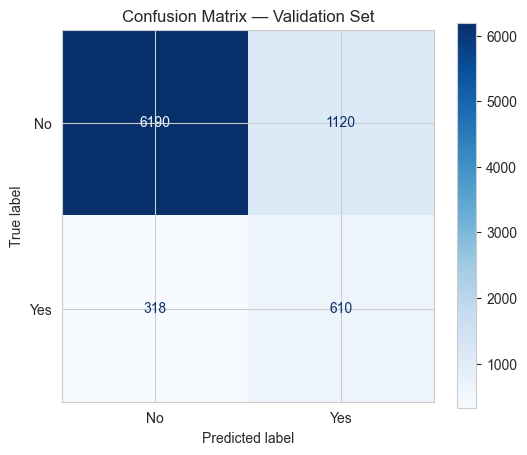


True Negatives:  6190
False Positives: 1120
False Negatives: 318
True Positives:  610


In [38]:
# confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix — Validation Set')
plt.show()

print(f"\nTrue Negatives:  {cm[0][0]}")
print(f"False Positives: {cm[0][1]}")
print(f"False Negatives: {cm[1][0]}")
print(f"True Positives:  {cm[1][1]}")

Accuracy (87.3%) is close to the Zero Rule baseline (88.7%), but that's expected — we want the model to predict "yes" sometimes, not just always say "no".

The better metric here is F1. The baseline's F1 is 0.0 (it never predicts "yes" so recall is zero). Our model gets F1 ≈ 0.50, catching about 56% of actual subscribers with 45% precision. In a marketing context that's a useful result — the model finds real leads rather than calling everyone.